# Lazada Customer Life Time Value

In [2]:
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes import BetaGeoFitter, GammaGammaFitter, plotting
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix, plot_period_transactions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.pipeline import Pipeline
import pandas as pd
import lifetimes

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)


In [3]:
df = pd.read_csv('lazada.csv')
df_orders =df
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,credit_card,3,179.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103881,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,1,credit_card,3,85.08
103882,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,1,credit_card,3,195.00
103883,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,1,credit_card,5,271.01
103884,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,1,credit_card,4,441.16


# Data Visulization and EDA

In [4]:
df.describe()

,customer_zip_code_prefix,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000,103886.000000
mean,35072.550555,1.092679,2.853349,154.100380
std,29743.491677,0.706584,2.687051,217.494064
min,1003.000000,1.000000,0.000000,0.000000
25%,11366.250000,1.000000,1.000000,56.790000
50%,24360.000000,1.000000,1.000000,100.000000
75%,58418.000000,1.000000,4.000000,171.837500
max,99990.000000,29.000000,24.000000,13664.080000


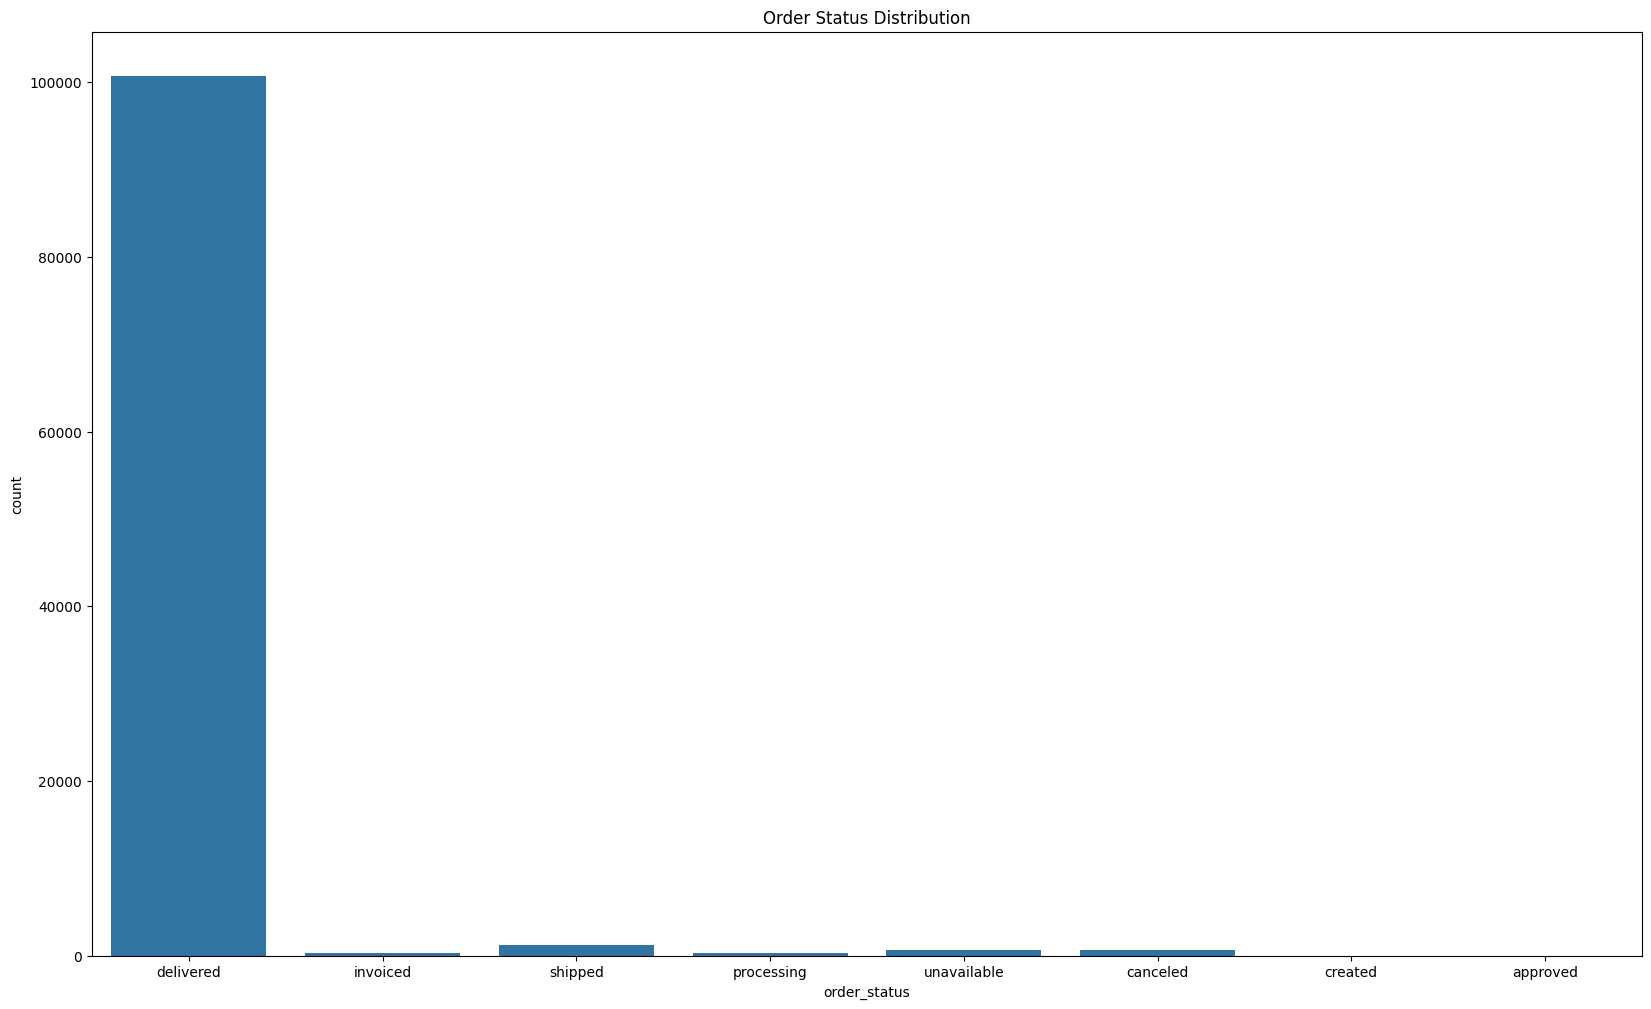

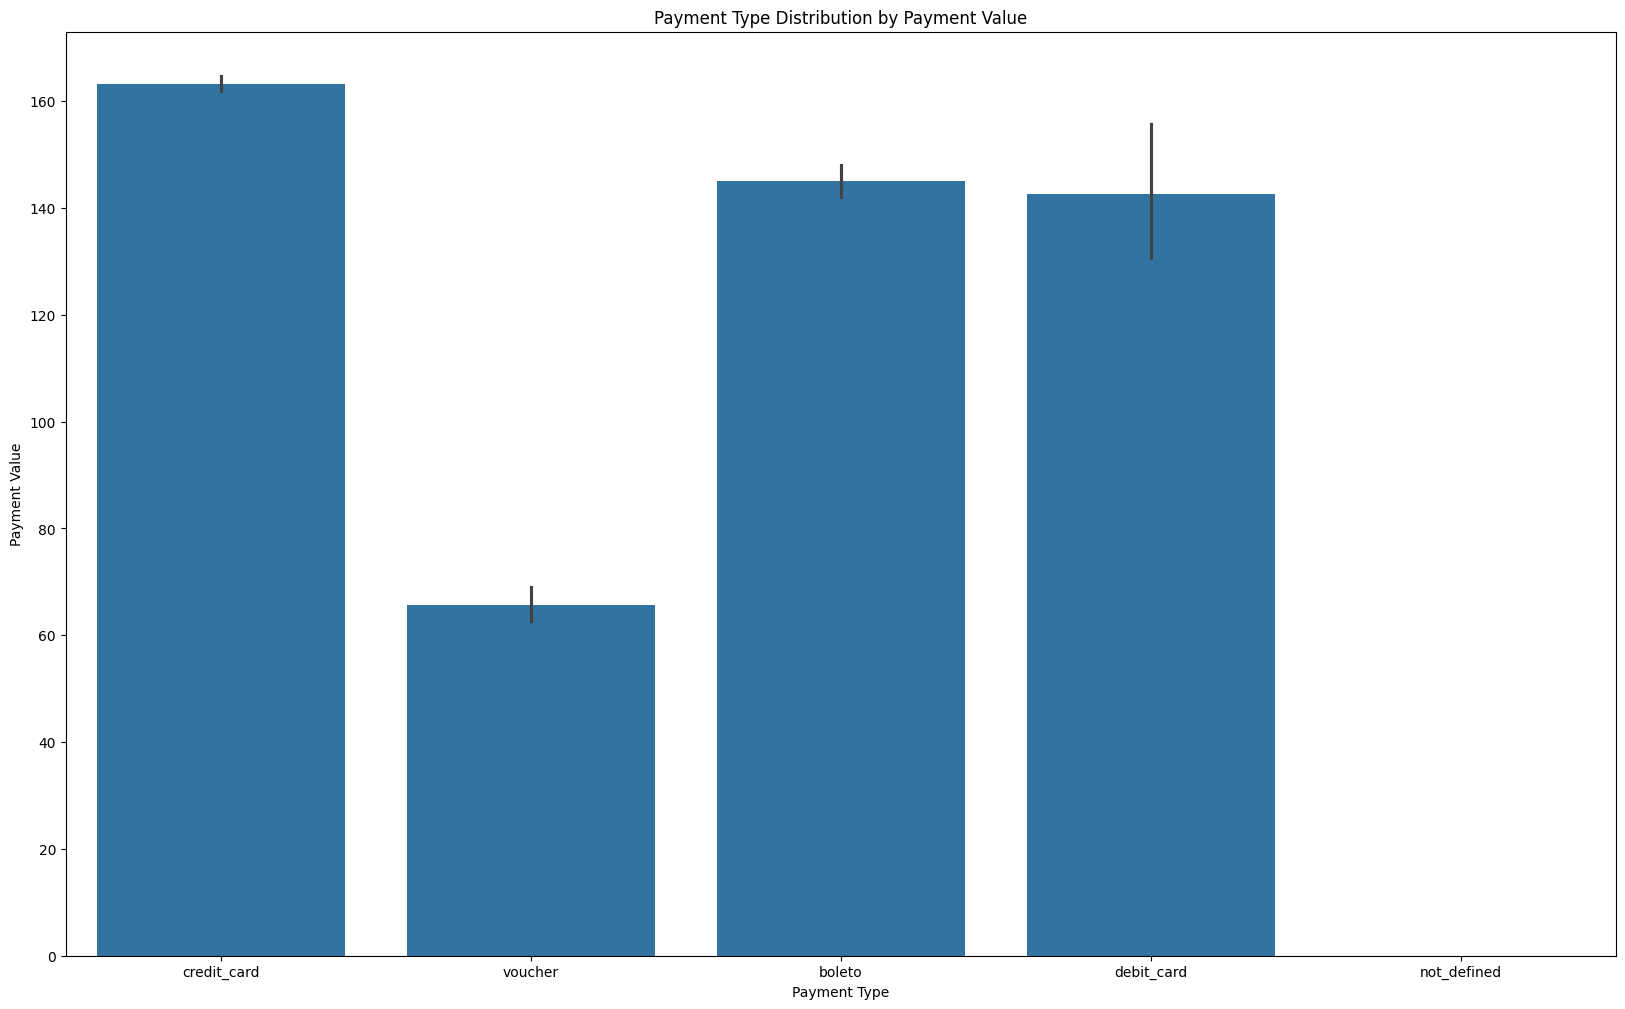

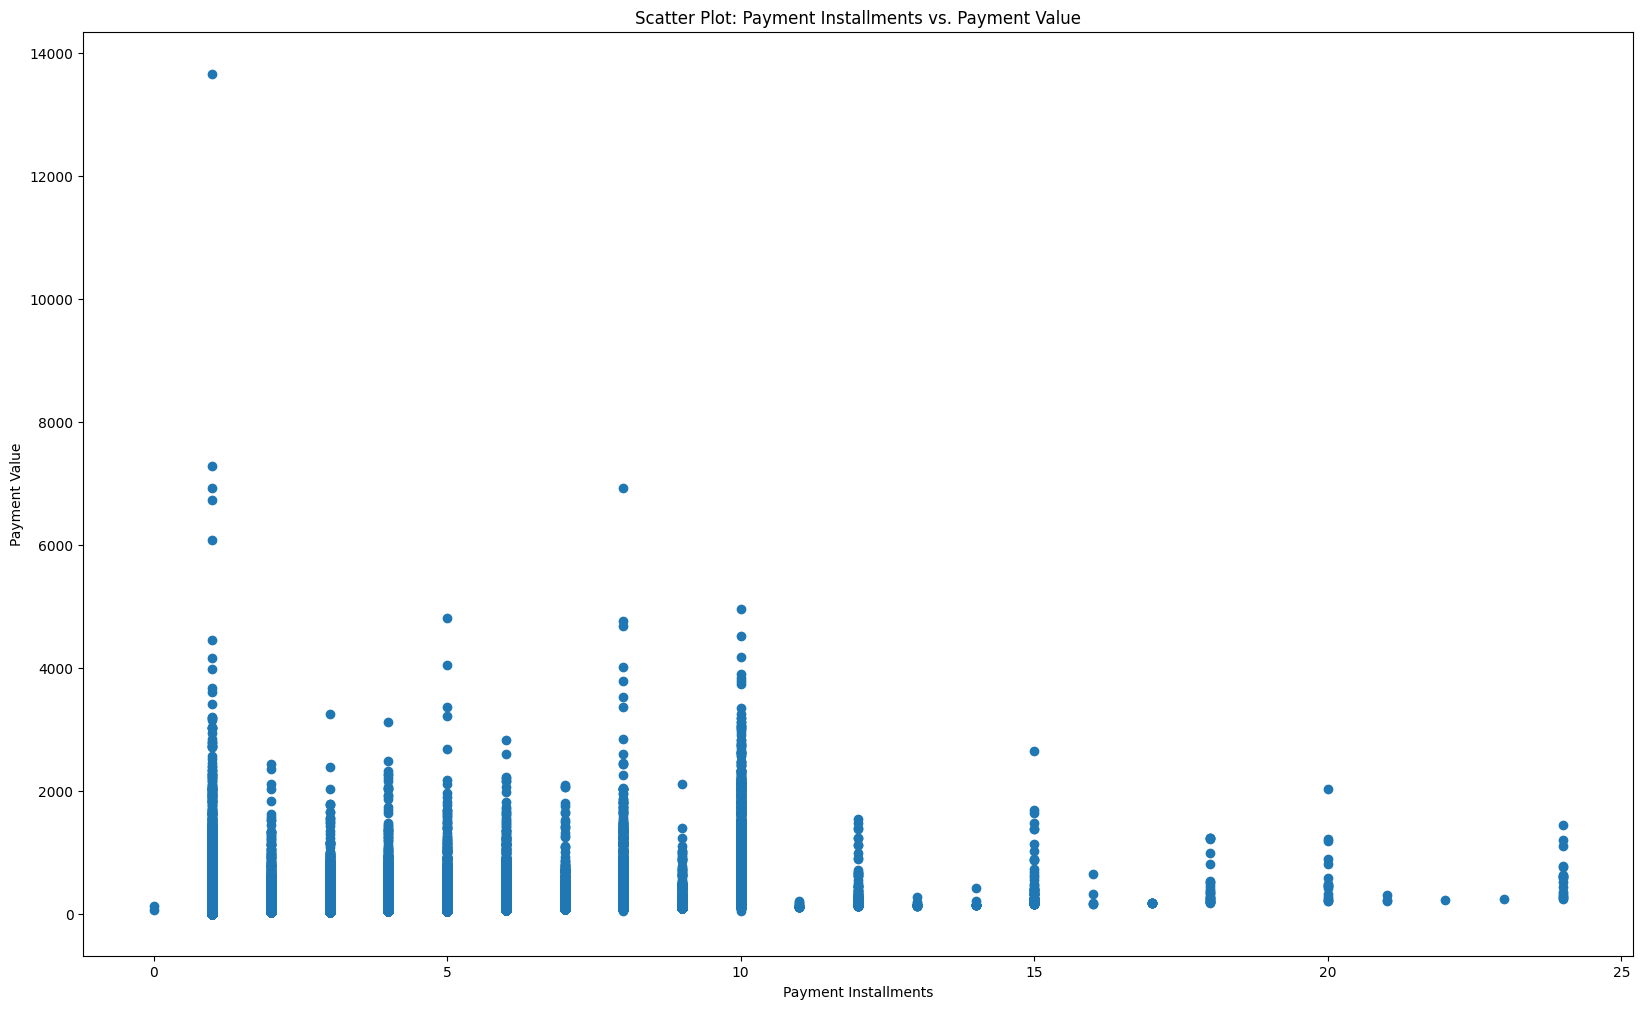

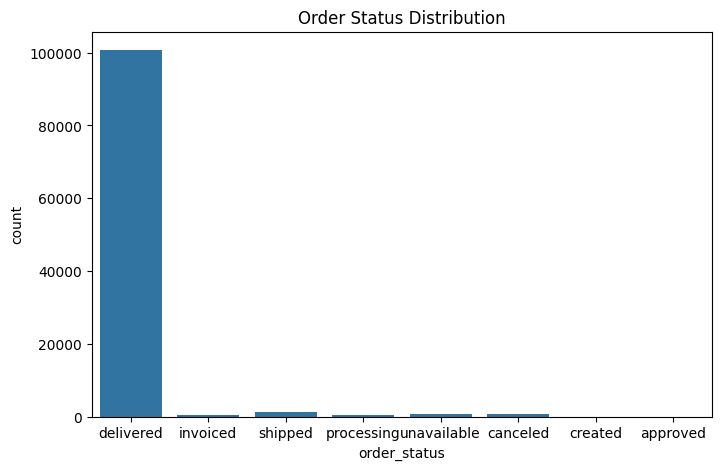

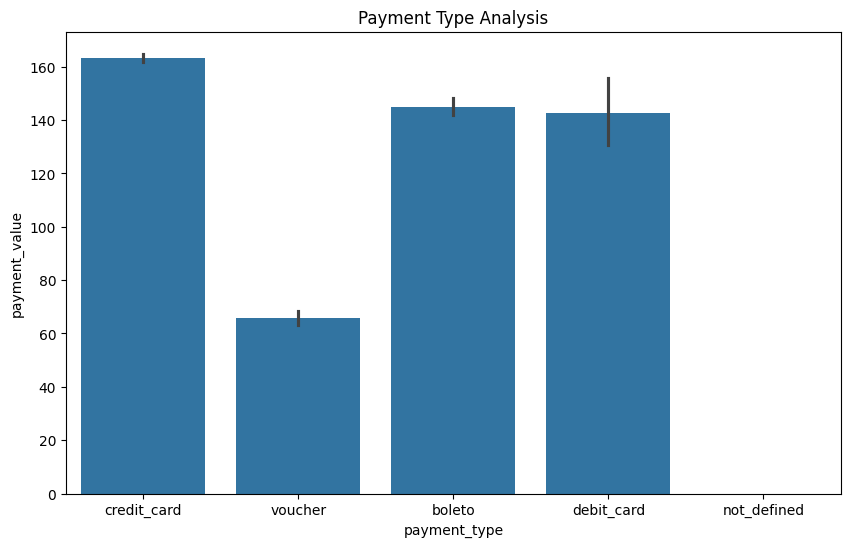

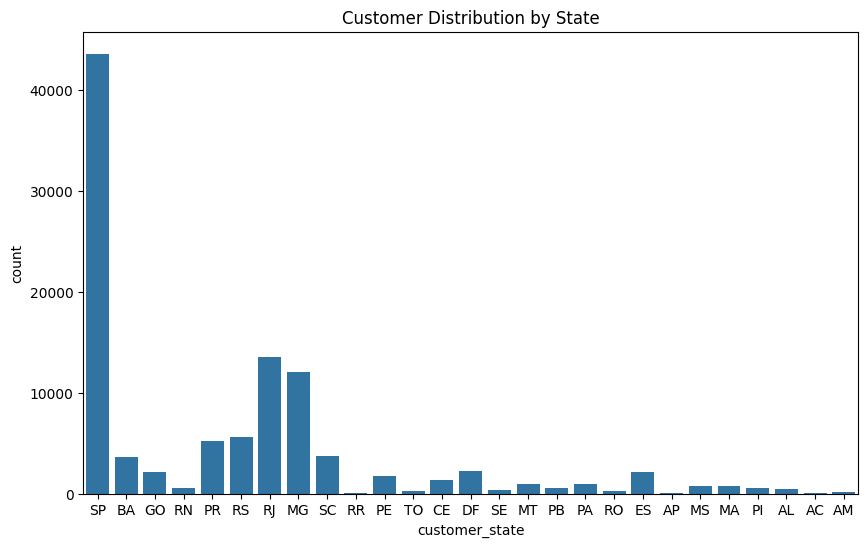

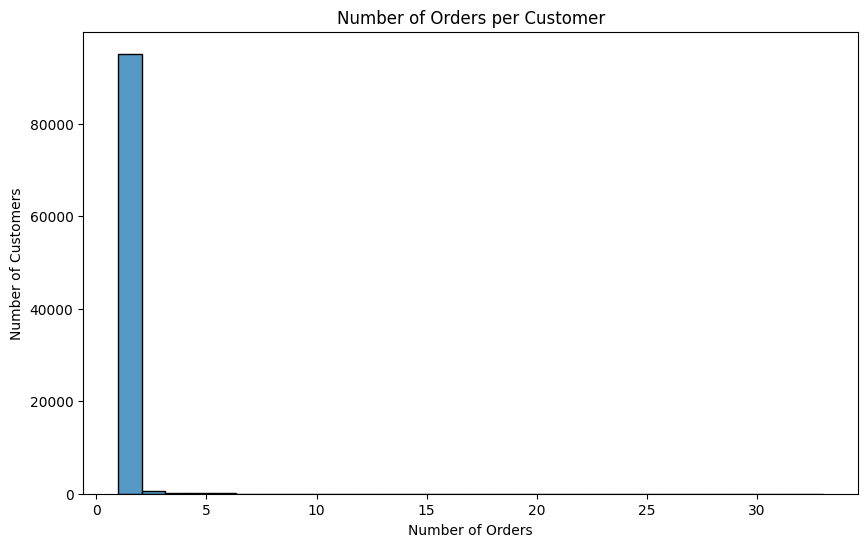

In [5]:
plt.figure(figsize=(20, 12))
# Convert timestamp columns to datetime format
timestamp_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
df_orders[timestamp_columns] = df_orders[timestamp_columns].apply(pd.to_datetime)

# Visualization 1: Count plot for order status
sns.countplot(x='order_status', data=df_orders)
plt.title('Order Status Distribution')
plt.show()

plt.figure(figsize=(20, 12))


# Visualization 3: Bar chart for payment type distribution
sns.barplot(x='payment_type', y='payment_value', data=df_orders)
plt.title('Payment Type Distribution by Payment Value')
plt.xlabel('Payment Type')
plt.ylabel('Payment Value')
plt.show()

plt.figure(figsize=(20, 12))

# Visualization 4: Scatter plot for payment installments and payment value
plt.scatter(df_orders['payment_installments'], df_orders['payment_value'])
plt.title('Scatter Plot: Payment Installments vs. Payment Value')
plt.xlabel('Payment Installments')
plt.ylabel('Payment Value')
plt.show()

# Order Status Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='order_status', data=df)
plt.title('Order Status Distribution')
plt.show()

# Payment Analysis
plt.figure(figsize=(10, 6))
sns.barplot(x='payment_type', y='payment_value', data=df)
plt.title('Payment Type Analysis')
plt.show()

# Geographical Analysis
plt.figure(figsize=(10, 6))
sns.countplot(x='customer_state', data=df)
plt.title('Customer Distribution by State')
plt.show()

# Customer Loyalty
plt.figure(figsize=(10, 6))
sns.histplot(df.groupby('customer_unique_id')['order_id'].count(), bins=30, kde=False)
plt.title('Number of Orders per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.show()



# Data Processing Feature Extraction and Clipping Outliers

In [6]:
df = df[df['payment_value'] > 0 ]
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,credit_card,3,179.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103881,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,1,credit_card,3,85.08
103882,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,1,credit_card,3,195.00
103883,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,1,credit_card,5,271.01
103884,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,1,credit_card,4,441.16


In [7]:
df.dropna(inplace=True)

In [8]:
def find_boundaries(df, variable,q1=0.05,q2=0.95):
    # the boundaries are the quantiles
    lower_boundary = df[variable].quantile(q1)
    upper_boundary = df[variable].quantile(q2)

    return upper_boundary, lower_boundary

def capping_outliers(df,variable):
    upper_boundary,lower_boundary =  find_boundaries(df,variable)
    df[variable] = np.where(df[variable] > upper_boundary, upper_boundary,
                       np.where(df[variable] < lower_boundary, lower_boundary, df[variable]))

In [9]:
capping_outliers(df,'payment_value')

# RMF Scoring

In [10]:
clv = lifetimes.utils.summary_data_from_transaction_data(df,'customer_unique_id','order_purchase_timestamp','payment_value')

In [11]:
clv = clv[clv['frequency']>1] # we want only customers shopped more than 2 times

In [12]:
clv

,frequency,recency,T,monetary_value
customer_unique_id,,,,
02e9109b7e0a985108b43e573b6afb23,2.0,172.0,279.0,117.065000
041caba6a63ace5818387698ea85cdb2,2.0,435.0,532.0,61.755000
07b1b60bca2b6326fa2adb259ea4a55f,2.0,44.0,156.0,81.240000
083ca1aa470c280236380973a48f77c6,2.0,19.0,397.0,86.960000
08c07c761592a71b85136aa4fe76a6f4,2.0,238.0,383.0,148.980000
08e5b38d7948d37fbb2a59fc5e175ab1,2.0,68.0,179.0,350.715000
0b18593e033697810a62a987e77f4b8c,2.0,284.0,453.0,68.235000
12d8b5ed661190a3a08183644dfc504d,3.0,402.0,521.0,234.716667
1373e04979cfa0fb2092909abbd57f25,2.0,92.0,210.0,196.305000


# Expected Transactions Determination

In [13]:
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(clv['frequency'], clv['recency'], clv['T'])

<lifetimes.BetaGeoFitter: fitted with 151 subjects, a: 1.43, alpha: 427.80, b: 4.62, r: 4.54>

In [14]:
# Assuming 'T' is the customer's age at the time of the last observation
t = clv['T'].max()
clv['expected_purchases_all_time'] = bgf.conditional_expected_number_of_purchases_up_to_time(t, clv['frequency'], clv['recency'], clv['T'])
top_customers = clv.sort_values(by='expected_purchases_all_time', ascending=False) 


In [15]:
clv

,frequency,recency,T,monetary_value,expected_purchases_all_time
customer_unique_id,,,,,
02e9109b7e0a985108b43e573b6afb23,2.0,172.0,279.0,117.065000,2.275735
041caba6a63ace5818387698ea85cdb2,2.0,435.0,532.0,61.755000,2.143295
07b1b60bca2b6326fa2adb259ea4a55f,2.0,44.0,156.0,81.240000,2.205456
083ca1aa470c280236380973a48f77c6,2.0,19.0,397.0,86.960000,0.238264
08c07c761592a71b85136aa4fe76a6f4,2.0,238.0,383.0,148.980000,1.887586
08e5b38d7948d37fbb2a59fc5e175ab1,2.0,68.0,179.0,350.715000,2.233284
0b18593e033697810a62a987e77f4b8c,2.0,284.0,453.0,68.235000,1.695359
12d8b5ed661190a3a08183644dfc504d,3.0,402.0,521.0,234.716667,2.355565
1373e04979cfa0fb2092909abbd57f25,2.0,92.0,210.0,196.305000,2.148682


# Expected Value Determination

In [16]:
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(clv["frequency"],
        clv["monetary_value"])

<lifetimes.GammaGammaFitter: fitted with 151 subjects, p: 4.12, q: 0.49, v: 4.00>

In [17]:
clv['All-time']=ggf.customer_lifetime_value(bgf,
                                   clv["frequency"],
                                   clv["recency"],
                                   clv["T"],
                                   clv["monetary_value"],
                                   time=t,
                                   freq='D',
                                   discount_rate=0.01)

In [18]:
 clv.sort_values('All-time',ascending=False)

,frequency,recency,T,monetary_value,expected_purchases_all_time,All-time
customer_unique_id,,,,,,
4facc2e6fbc2bffab2fea92d2b4aa7e4,3.0,421.0,437.0,386.217000,3.204760,2280.186523
397b44d5bb99eabf54ea9c2b41ebb905,3.0,157.0,230.0,353.950333,3.132502,1896.602866
d132b863416f85f2abb1a988ca05dd12,2.0,341.0,380.0,335.535500,2.694553,1678.616646
297ec5afd18366f5ba27520cc4954151,2.0,85.0,194.0,409.650500,2.265761,1604.654788
8961b4ca2c5aceb7a78ea72c6e0c840a,2.0,208.0,275.0,314.410000,2.675156,1504.034763
fe81bb32c243a86b2f86fbf053fe6140,4.0,242.0,311.0,230.730250,3.498312,1407.048288
7849336c1b7785f258ffef06aedbd216,2.0,307.0,343.0,264.580500,2.786909,1353.581419
08e5b38d7948d37fbb2a59fc5e175ab1,2.0,68.0,179.0,350.715000,2.233284,1346.693855
3ea4185126195c34ed9949d8e406d570,2.0,381.0,423.0,256.000500,2.597627,1254.920412


# Cutsomer Segemnetation

In [19]:
clv['Segment'] =  pd.qcut(clv['All-time'],4,labels = ['Inactive','Requires Attension',
                                     'Loyal Customers','Gold Members (Premiun)'])

In [20]:
clv

,frequency,recency,T,monetary_value,expected_purchases_all_time,All-time,Segment
customer_unique_id,,,,,,,
02e9109b7e0a985108b43e573b6afb23,2.0,172.0,279.0,117.065000,2.275735,482.195505,Loyal Customers
041caba6a63ace5818387698ea85cdb2,2.0,435.0,532.0,61.755000,2.143295,264.750586,Requires Attension
07b1b60bca2b6326fa2adb259ea4a55f,2.0,44.0,156.0,81.240000,2.205456,310.768247,Requires Attension
083ca1aa470c280236380973a48f77c6,2.0,19.0,397.0,86.960000,0.238264,39.346545,Inactive
08c07c761592a71b85136aa4fe76a6f4,2.0,238.0,383.0,148.980000,1.887586,526.521456,Loyal Customers
08e5b38d7948d37fbb2a59fc5e175ab1,2.0,68.0,179.0,350.715000,2.233284,1346.693855,Gold Members (Premiun)
0b18593e033697810a62a987e77f4b8c,2.0,284.0,453.0,68.235000,1.695359,225.142816,Requires Attension
12d8b5ed661190a3a08183644dfc504d,3.0,402.0,521.0,234.716667,2.355565,1047.955488,Gold Members (Premiun)
1373e04979cfa0fb2092909abbd57f25,2.0,92.0,210.0,196.305000,2.148682,737.926147,Gold Members (Premiun)


# Regressor Training/Evalaution for Lifetime Value Prediction

In [21]:
# Regressor Training/Evalaution for Lifetime Value Prediction# Separate features and target variable for CLV prediction
clv_features = clv[['frequency', 'recency', 'T', 'monetary_value' ]]
clv_target = clv['All-time']

# Split the data into training and testing sets for CLV prediction
clv_X_train, clv_X_test, clv_y_train, clv_y_test = train_test_split(clv_features, clv_target, test_size=0.2, random_state=42)

# Train a Linear Regression model for CLV prediction
clv_model = LinearRegression()
clv_model.fit(clv_X_train, clv_y_train)

# Make predictions on the test set
clv_predictions = clv_model.predict(clv_X_test)

# Evaluate the CLV prediction model
mse = mean_squared_error(clv_y_test, clv_predictions)
print(f'Mean Squared Error for CLV Prediction: {mse}')

Mean Squared Error for CLV Prediction: 23785.68185267049


In [22]:
 
# Standardize features for Random Forest Regressor
scaler = StandardScaler()
clv_X_train_scaled = scaler.fit_transform(clv_X_train)
clv_X_test_scaled = scaler.transform(clv_X_test)

# Train a Random Forest Regressor for CLV prediction
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(clv_X_train_scaled, clv_y_train)

# Make predictions on the test set
clv_predictions_rf = rf_model.predict(clv_X_test_scaled)

# Evaluate the Random Forest Regressor model
mse_rf = mean_squared_error(clv_y_test, clv_predictions_rf)
print(f'Mean Squared Error for CLV Prediction (Random Forest): {mse_rf}')

Mean Squared Error for CLV Prediction (Random Forest): 19198.688699240425


# Classifier Training/Evalaution for Customer Segmentation

In [23]:
# Classifier Training/Evalaution for Customer Segmentation# Separate features and target variable for Segment prediction
segment_features = clv[['frequency', 'recency', 'T', 'monetary_value', 'All-time']]
segment_target = clv['Segment']

# Split the data into training and testing sets for Segment prediction
segment_X_train, segment_X_test, segment_y_train, segment_y_test = train_test_split(segment_features, segment_target, test_size=0.2, random_state=42)

# Create a pipeline for preprocessing and training the Random Forest Classifier
segment_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Train the Random Forest Classifier for Segment prediction
segment_pipeline.fit(segment_X_train, segment_y_train)

# Make predictions on the test set
segment_predictions = segment_pipeline.predict(segment_X_test)

# Evaluate the Segment prediction model
accuracy = accuracy_score(segment_y_test, segment_predictions)
print(f'Accuracy for Segment Prediction: {accuracy}')

# Display classification report for more detailed metrics
print(classification_report(segment_y_test, segment_predictions))

Accuracy for Segment Prediction: 0.967741935483871
                        precision    recall  f1-score   support

Gold Members (Premiun)       1.00      1.00      1.00         6
              Inactive       1.00      1.00      1.00         8
       Loyal Customers       1.00      0.89      0.94         9
    Requires Attension       0.89      1.00      0.94         8

              accuracy                           0.97        31
             macro avg       0.97      0.97      0.97        31
          weighted avg       0.97      0.97      0.97        31



# Saving Models

In [24]:
import joblib

# Save Random Forest Regressor model for CLV prediction
joblib.dump(rf_model, 'clv_rf_model.joblib')

# Save Segment prediction pipeline
joblib.dump(segment_pipeline, 'segment_pipeline.joblib')

scaler_filename = 'standard_scaler.joblib'
joblib.dump(scaler, scaler_filename)
print(f'StandardScaler object saved to {scaler_filename}')

StandardScaler object saved to standard_scaler.joblib


# Prediction Fucntions

In [25]:
def predict_clv(new_customer_features):
    # Ensure that the new customer features are in the correct order
    new_customer_features = pd.DataFrame([new_customer_features], columns=['frequency', 'recency', 'T', 'monetary_value'])

    # Standardize the features for the Random Forest Regressor
    new_customer_features_scaled = scaler.transform(new_customer_features)

    # Predict CLV using the Random Forest Regressor
    clv_prediction = rf_model.predict(new_customer_features_scaled)[0]
    return clv_prediction

# Example usage:
new_customer_features = [58, 100, 150, 5000]  # Replace with the actual features of the new customer
predicted_clv = predict_clv(new_customer_features)

print(f'Predicted Segment: {predicted_clv}')


Predicted Segment: 1699.5379310737449


In [26]:
def predict_segment(new_customer_features):
    # Ensure that the new customer features are in the correct order
    new_customer_features = pd.DataFrame([new_customer_features], columns=['frequency', 'recency', 'T', 'monetary_value', 'All-time'])

    # Use the trained pipeline to standardize features and predict segment
    new_customer_segment = segment_pipeline.predict(new_customer_features)[0]
    return new_customer_segment

# Example usage:
new_customer_features = [58, 100, 150, 5000, 1000]  # Replace with the actual features of the new customer
predicted_segment = predict_segment(new_customer_features)

print(f'Predicted Segment: {predicted_segment}')


Predicted Segment: Gold Members (Premiun)


End of Notebook